# Datos sintéticos del proyecto: qué son, cómo se crean y para qué sirven

**Equipo 39 · Proyecto Integrador MNA**

Este notebook explica, para alguien que no conoce el proyecto, los **datos sintéticos** que usamos. Se puede ejecutar completo de principio a fin (*Run All*) y tarda menos de un minuto.

**En tres frases:**
1. Queremos medir qué tan rígido es el material de una viga microscópica (su **módulo de Young, E**) a partir de cómo vibra.
2. Las fórmulas que se usan para eso suponen una viga "perfecta", y las vigas reales no lo son; eso produce errores en E.
3. Para estudiar esos errores fabricamos datos de vigas "imperfectas" por computadora, donde **sí conocemos el E verdadero**, y así podemos medir cuánto se equivoca cada método.

### Contenido
1. [Nombres y términos](#1.-Nombres-y-términos)
2. [El problema](#2.-El-problema)
3. [Qué se mide en una viga que vibra](#3.-Qué-se-mide-en-una-viga-que-vibra)
4. [Cómo calculamos la vibración y cómo sabemos que el cálculo es correcto](#4.-Cómo-calculamos-la-vibración-y-cómo-sabemos-que-el-cálculo-es-correcto)
5. [Los cuatro generadores: vigas perfectas e imperfectas](#5.-Los-cuatro-generadores:-vigas-perfectas-e-imperfectas)
6. [Qué tan imperfectas: la severidad](#6.-Qué-tan-imperfectas:-la-severidad)
7. [Un conjunto de datos, paso a paso](#7.-Un-conjunto-de-datos,-paso-a-paso)
8. [Cómo se usarán los datos](#8.-Cómo-se-usarán-los-datos)
9. [Limitaciones y pendientes](#9.-Limitaciones-y-pendientes)

## 1. Nombres y términos

A lo largo del notebook usamos algunos nombres cortos. Aquí están todos; cada sección los vuelve a explicar con más detalle.

**Física y dispositivos**

| Término | Significado |
|---|---|
| **MEMS** | Sistemas microelectromecánicos: piezas mecánicas del tamaño de micras fabricadas como chips |
| **Viga en voladizo** | Viga sujeta de un solo extremo, como un trampolín |
| **Viga biempotrada** | Viga sujeta de ambos extremos, como un puente |
| **Módulo de Young, E** | Qué tan rígido es un material. Es el número que queremos medir |
| **Tensión residual, σ₀** | Esfuerzo que queda atrapado en la viga al fabricarla: la deja estirada o comprimida (ver abajo) |
| **Modo de vibración** | Cada manera natural en que puede vibrar una viga, con su propia frecuencia ω (ver abajo) |
| **Forma modal** | El dibujo que hace la viga al vibrar en un modo: qué puntos se mueven y cuánto (ver abajo) |
| **ξ** (xi) | Posición a lo largo de la viga, de 0 (soporte) a 1 (punta) |
| **Euler–Bernoulli** | La ecuación estándar de vibración de una viga delgada: el "modelo simple" |
| **Timoshenko** | Una versión más completa que agrega la deformación por cortante; importa en vigas cortas y gruesas |


### Tres conceptos clave, con ejemplos

**Modo de vibración.** Piensa en una regla que sobresale del borde de una mesa. Si le das un golpecito, oscila de arriba abajo de la forma más sencilla posible: todo el tramo libre se mueve hacia el mismo lado. Ese es el **modo 1**, el más lento. Si la excitas con más energía y a la frecuencia adecuada, también puede vibrar en patrones más complejos, con una parte que sube mientras otra baja y con puntos intermedios que se quedan quietos (llamados **nodos**). Esos son el **modo 2**, el **modo 3**, etc., cada uno más rápido que el anterior. Es lo mismo que pasa con una cuerda de guitarra y sus armónicos. Cada modo tiene su propia **frecuencia natural** ω. En nuestra viga en voladizo de 300 µm, los tres primeros modos vibran a unos 28, 174 y 487 kHz: decenas de miles de veces por segundo, demasiado rápido para verlo, pero medible con un láser.

**Forma modal.** Es el "dibujo" que hace la viga cuando vibra en un modo: si congeláramos la viga en el instante de máxima deformación, veríamos su forma modal. En el voladizo, la del modo 1 es una curva suave que va desde cero en el soporte hasta el máximo en la punta; la del modo 2 cruza una vez por cero (un nodo) y la del modo 3, dos veces. La gráfica de la sección 3 muestra las seis formas (tres por estructura). En el laboratorio se mide con un vibrómetro láser que apunta a N puntos a lo largo de la viga. Lo que importa es la **forma**, no el tamaño: la misma viga puede vibrar con más o menos amplitud según qué tan fuerte se la excite, por eso normalizamos todas las formas a un máximo de 1.

**Tensión residual σ₀.** Las vigas MEMS se fabrican depositando una película delgada de material (aquí, óxido de silicio) sobre una oblea de silicio, a temperaturas altas. Al enfriarse, la película y la oblea se contraen de manera distinta, y cuando la viga se libera queda con un esfuerzo "atrapado" que nadie le aplicó a propósito: la **tensión residual**. Es como el parche de un tambor: si está estirado (**tensión**, σ₀ > 0) suena más agudo; si está flojo o comprimido (**compresión**, σ₀ < 0) suena más grave.

En una viga **biempotrada** el efecto es fuerte porque sus dos extremos están fijos y no puede acomodarse. Por ejemplo, en nuestra viga biempotrada de 300 µm, la frecuencia del modo 1 es de 177 kHz sin tensión residual; con una tensión de apenas 20 MPa sube a 249 kHz (+41%), y con una compresión de 10 MPa baja a 124 kHz. Si la compresión pasa de unos 19 MPa, la viga ya no aguanta recta y se **pandea**: se arquea hacia arriba o hacia abajo. En una viga en **voladizo** la tensión residual casi no importa, porque su extremo libre deja que el material se relaje. Por eso, si no se toma en cuenta σ₀, un método puede confundir su efecto con un cambio en E.

**Los generadores de datos (M0–M3).** Cada uno es una forma distinta de fabricar datos de una viga; M0 es perfecta y M1–M3 tienen una imperfección que el modelo simple ignora:

| Nombre | Viga que simula |
|---|---|
| **M0** | Viga perfecta: lo que supone el modelo simple. Sirve de control |
| **M1** | El soporte gira un poco, como un resorte |
| **M2** | Viga corta y gruesa, donde importa el cortante (Timoshenko) |
| **M3** | El espesor cambia a lo largo de la viga |

**Niveles de severidad (s1–s6).** Solo para M1: seis grados de flexibilidad del soporte, de casi rígido (s1) a muy flexible (s6). Cada nivel corresponde a un error en E de 1, 2.5, 5, 10, 15 y 25% si se usa la fórmula ideal. La flexibilidad se describe con el número **κ_θ** (kappa theta): grande = soporte rígido, pequeño = soporte flexible.

**Niveles de método (L0–L3).** Agrupan los métodos que se van a comparar según cuánto desconfían del modelo simple:

| Nombre | Idea |
|---|---|
| **L0** | Confía totalmente en el modelo simple |
| **L1** | Permite que los datos se aparten un poco de la física |
| **L2** | Agrega un término genérico de corrección |
| **L3** | Agrega la física que le falta al modelo simple |

**Datos y experimento**

| Término | Significado |
|---|---|
| **Datos sintéticos** | Datos fabricados por computadora con un modelo físico, donde conocemos la respuesta correcta |
| **Mala especificación** | La diferencia entre el modelo que genera los datos y el modelo simple que usan los métodos |
| **Severidad** | Qué tan grande es la mala especificación, medida como el error en E que produce |
| **Ruido** | Error aleatorio que se suma a las mediciones simuladas (2%) |
| **Semilla** | Número que fija el ruido aleatorio: misma semilla, mismos datos |
| **N** | Número de puntos donde se mide la forma modal |
| **PINN** | Red neuronal informada por la física: una red que se entrena respetando una ecuación física |
| **λ, κ_θ, W** | Versiones sin unidades de la frecuencia, la rigidez del soporte y el desplazamiento (sección 8) |

**Fuentes que se mencionan**

| Nombre | Qué es |
|---|---|
| **NIST** | Instituto Nacional de Estándares y Tecnología de EE. UU. |
| **RM 8096** | Material de referencia del NIST: un chip con vigas de óxido de silicio cuya geometría usamos |
| **M-TEST** | Método de medición de propiedades de MEMS (Osterberg y Senturia, 1997); de ahí sale el error típico de 5% por el soporte |
| **Kobrinsky et al. (2000)** | Artículo con valores medidos de la rigidez de soportes de vigas MEMS |

### Preparación

Esta celda localiza el código del proyecto (`src/pinn_mems`) y carga las librerías. Funciona aunque el paquete no esté instalado, siempre que el notebook se abra desde el repositorio. Requiere `numpy`, `scipy`, `pyyaml`, `matplotlib` y `pandas`.

In [1]:
import sys
from pathlib import Path

# Busca la raíz del repositorio subiendo desde la carpeta actual
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "pinn_mems").is_dir())
sys.path.insert(0, str(RAIZ / "src"))

import math
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pinn_mems import Conjunto, Soporte, Viga, cargar_config, generar, resolver_modos
from pinn_mems.adimensional import Escalas
from pinn_mems.eigensolver import Timoshenko
from pinn_mems.severidad import severidad

CONFIGS = RAIZ / "datos" / "sinteticos" / "configs"
CALIBRACION = pd.read_csv(RAIZ / "datos" / "sinteticos" / "calibracion.csv")

# Paleta fija para todas las gráficas (azul, naranja, verde)
COLORES = ["#2a78d6", "#eb6834", "#1baf7a"]
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
    "lines.linewidth": 2, "figure.dpi": 110, "axes.axisbelow": True,
})
pd.set_option("display.precision", 2)
print("Repositorio:", RAIZ)

Repositorio: /home/mnlvzqz/code/Integrador/team39-datos-sinteticos


## 2. El problema

Los fabricantes de chips MEMS necesitan conocer el módulo de Young E de sus materiales, porque de él depende cómo se comportan sus dispositivos. Una forma estándar de medirlo es **hacer vibrar una viga microscópica** y medir su frecuencia: una viga más rígida vibra más rápido. Con una fórmula se despeja E a partir de la frecuencia.

El problema es que esa fórmula supone una viga **ideal**: espesor perfectamente uniforme y un soporte que no se mueve nada. En la realidad el soporte cede un poco, el espesor varía, etc. La fórmula no sabe nada de eso y atribuye cualquier diferencia a E, así que **el E calculado sale sesgado**. Por ejemplo, el Instituto Nacional de Estándares de EE. UU. (NIST) midió vigas de 200, 300 y 400 µm del mismo material y obtuvo un E distinto según la longitud, un síntoma típico de este problema.

**La pregunta del proyecto:** ¿qué métodos (clásicos o con redes neuronales PINN) extraen mejor E cuando el modelo físico está un poco equivocado?

**Por qué datos sintéticos:** con datos reales nunca sabemos cuál es el E verdadero, así que no podemos medir el error de un método. Con datos sintéticos sí:

```
  1. GENERAR             2. INVERTIR                    3. COMPARAR
  Viga "imperfecta"  →   Cada método estima E con   →   E estimado vs. E verdadero
  con E conocido         el modelo ideal (simple)       = error del método
```

La diferencia entre el modelo que genera los datos y el modelo simple que usan los métodos se llama **mala especificación**. Es exactamente lo que queremos estudiar.

## 3. Qué se mide en una viga que vibra

Usamos como referencia la geometría de un material de referencia real del NIST (**RM 8096**): vigas de óxido de silicio, del tamaño de un cabello de ancho y unas 30 veces más delgadas.

In [2]:
viga = Viga(E=70e9, L=300e-6, b=28e-6, h=2.743e-6, rho=2200.0)

pd.DataFrame({
    "valor": ["300 µm", "28 µm", "2.743 µm", "2200 kg/m³", "70 GPa"],
    "significado": ["longitud", "ancho", "espesor", "densidad del óxido de silicio",
                    "módulo de Young (valor verdadero)"],
}, index=["L", "b", "h", "ρ", "E"])

,valor,significado
L,300 µm,longitud
b,28 µm,ancho
h,2.743 µm,espesor
ρ,2200 kg/m³,densidad del óxido de silicio
E,70 GPa,módulo de Young (valor verdadero)


De cada viga se pueden medir dos cosas:

- **Frecuencias** de los primeros modos (ω₁, ω₂, ω₃): qué tan rápido vibra en cada forma.
- **Formas modales**: el perfil de la viga en cada modo, medido en N puntos a lo largo de ella (con un vibrómetro láser, por ejemplo).

Usamos la posición adimensional **ξ = x/L**, que va de 0 (soporte) a 1 (punta). Así todas las vigas se describen en la misma escala.

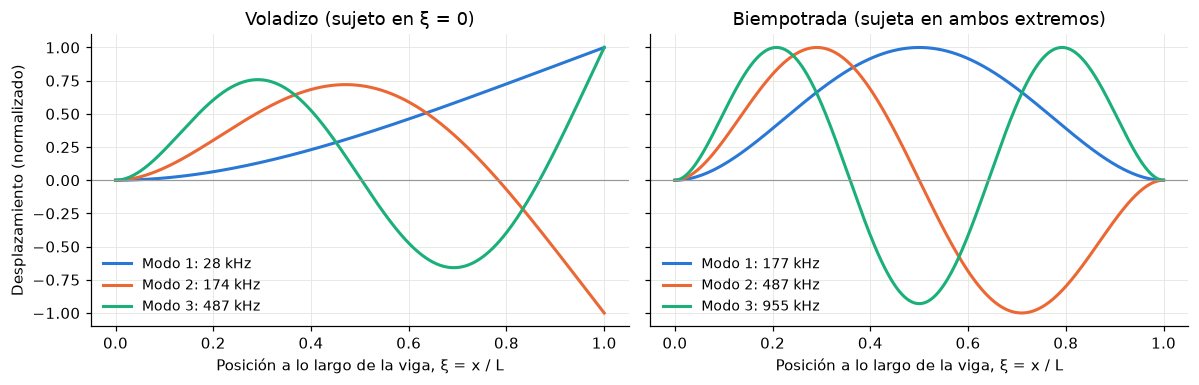

In [3]:
voladizo = resolver_modos(viga, "voladizo")
biempotrada = resolver_modos(viga, "biempotrada")

xi = np.linspace(0, 1, 400)
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for eje, (nombre, modos) in zip(ejes, [("Voladizo (sujeto en ξ = 0)", voladizo),
                                        ("Biempotrada (sujeta en ambos extremos)", biempotrada)]):
    w = modos.forma(xi)
    for m in range(3):
        eje.plot(xi, w[m], color=COLORES[m],
                 label=f"Modo {m + 1}: {modos.frecuencias_hz[m] / 1e3:.0f} kHz")
    eje.axhline(0, color="#999", linewidth=0.8)
    eje.set_title(nombre)
    eje.set_xlabel("Posición a lo largo de la viga, ξ = x / L")
    eje.legend(frameon=False, fontsize=9)
ejes[0].set_ylabel("Desplazamiento (normalizado)")
fig.tight_layout()

Las formas tienen **amplitud arbitraria** (depende de qué tan fuerte se excite la viga), así que las normalizamos para que su valor máximo sea 1. Lo que importa es su forma y su frecuencia.

## 4. Cómo calculamos la vibración y cómo sabemos que el cálculo es correcto

La vibración de una viga delgada se describe con la **ecuación de Euler–Bernoulli**:

  E·I·w⁗ − N·w″ − ω²·ρA·w = 0

donde w es el desplazamiento, I y A dependen de la sección (b, h), N es la tensión axial y ω la frecuencia. El código la resuelve con **elementos finitos**: divide la viga en 200 tramos, resuelve un problema de álgebra lineal y obtiene frecuencias y formas en milisegundos.

Antes de confiar en el código, lo comparamos con **soluciones exactas de libro de texto**. Para vigas ideales, ω = (βL)²·√(EI / ρAL⁴), con valores βL conocidos. El proyecto exige un error menor a 0.1%; obtenemos errores un millón de veces menores. Hay 85 pruebas automáticas más en `tests/` (con tensión, pandeo, soportes flexibles, cortante y conicidad).

In [4]:
raices = {"voladizo": [1.8751040687, 4.6940911330, 7.8547574382],
          "biempotrada": [4.7300407449, 7.8532046241, 10.9956078380]}
escala = math.sqrt(viga.EI / (viga.rho * viga.A * viga.L**4))
filas = []
for nombre, modos in [("voladizo", voladizo), ("biempotrada", biempotrada)]:
    for m in range(3):
        exacta = raices[nombre][m] ** 2 * escala
        filas.append({"estructura": nombre, "modo": m + 1,
                      "exacta (kHz)": exacta / (2 * np.pi * 1e3),
                      "calculada (kHz)": modos.frecuencias_hz[m] / 1e3,
                      "error relativo": f"{abs(modos.omega[m] / exacta - 1):.1e}"})
pd.DataFrame(filas).set_index(["estructura", "modo"])

exacta (kHz)  calculada (kHz) error relativo
estructura  modo                                              
voladizo    1            27.77            27.77        2.5e-08
            2           174.04           174.04        1.3e-09
            3           487.32           487.32        1.5e-09
biempotrada 1           176.72           176.72        1.5e-09
            2           487.13           487.13        1.5e-09
            3           954.97           954.97        6.3e-09

## 5. Los cuatro generadores: vigas perfectas e imperfectas

Los datos se generan con cuatro modelos, de M0 (perfecto) a M3. Los métodos que evaluaremos **siempre** usan el modelo simple (M0). Cada generador agrega una imperfección real que el modelo simple ignora:

| Generador | Qué agrega | Situación real | Cuántos niveles |
|---|---|---|---|
| **M0** | Nada: viga ideal | Control: todos los métodos deberían acertar | 1 |
| **M1** | El soporte **gira un poco**, como un resorte | El anclaje de una viga real nunca es perfectamente rígido | **6** (eje principal) |
| **M2** | **Cortante** e inercia de rotación (teoría de Timoshenko) | Vigas cortas y gruesas | 1 |
| **M3** | El espesor **varía linealmente** a lo largo de la viga | El grabado químico no es uniforme en el chip | 1 |

M1 es el caso principal porque es la explicación más probable del efecto que vio el NIST. M2 y M3 son una prueba de control: *¿el método que funciona bien con M1 sigue funcionando cuando el error tiene otra causa?*

A simple vista las formas de M1–M3 son casi idénticas a las de M0. Por eso graficamos la **diferencia** con M0: es la "huella" de cada imperfección, lo que un buen método tendría que detectar.

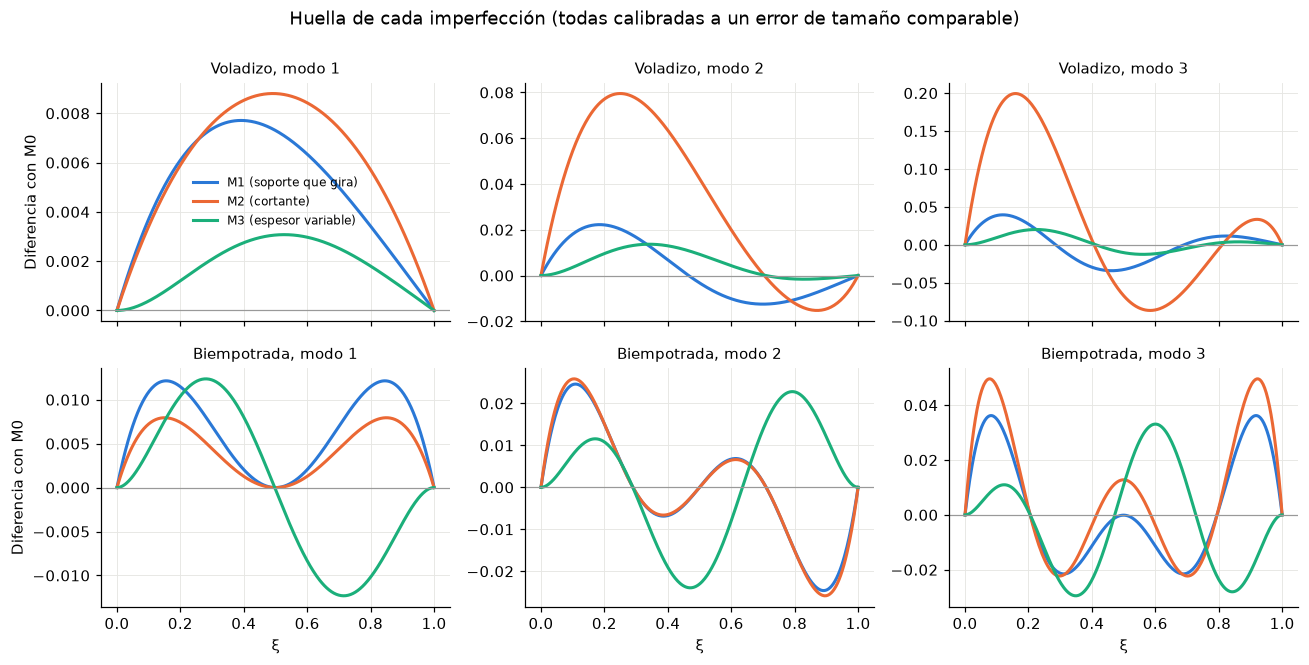

In [5]:
def fila_cal(nombre):
    return CALIBRACION.query("nombre == @nombre").iloc[0]

fig, ejes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for fila_ejes, est in zip(ejes, ["voladizo", "biempotrada"]):
    m0 = resolver_modos(viga, est).forma(xi)
    corta = Viga(**{**viga.__dict__, "L": float(fila_cal(f"m2_{est}").L)})
    huellas = {
        "M1 (soporte que gira)":
            resolver_modos(viga, est, Soporte(kappa_theta=float(fila_cal(f"m1_{est}_s3").kappa_theta))).forma(xi) - m0,
        "M2 (cortante)":
            resolver_modos(corta, est, timoshenko=Timoshenko()).forma(xi) - resolver_modos(corta, est).forma(xi),
        "M3 (espesor variable)":
            resolver_modos(viga, est, alpha=float(fila_cal(f"m3_{est}").alpha)).forma(xi) - m0,
    }
    for m, eje in enumerate(fila_ejes):
        for c, (nombre, d) in enumerate(huellas.items()):
            eje.plot(xi, d[m], color=COLORES[c], label=nombre)
        eje.axhline(0, color="#999", linewidth=0.8)
        eje.set_title(f"{est.capitalize()}, modo {m + 1}", fontsize=10)
    fila_ejes[0].set_ylabel("Diferencia con M0")
for eje in ejes[-1]:
    eje.set_xlabel("ξ")
ejes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Huella de cada imperfección (todas calibradas a un error de tamaño comparable)", y=1.0)
fig.tight_layout()

**Qué se ve:**
- **M1** cambia la forma sobre todo cerca del soporte, que ahora puede girar.
- **M2** casi no afecta al modo 1, pero deforma mucho los modos 2 y 3.
- **M3** en la biempotrada rompe la simetría de la viga: cambia la forma, pero casi no la frecuencia.
- En la biempotrada, **M1 y M2 dejan huellas muy parecidas**. Un método podría confundir una causa con la otra; M2 sirve justamente para comprobarlo.

## 6. Qué tan imperfectas: la severidad

Para M1 necesitamos decidir **qué tan flexible** es el soporte. Lo medimos con la **severidad**: el error que comete quien calcula E con la fórmula ideal. Como la frecuencia al cuadrado es proporcional a E:

  error en E = (ω₁ de la viga imperfecta / ω₁ de la viga ideal)² − 1

La flexibilidad del soporte se describe con un número adimensional, **κ_θ** (kappa): grande = soporte casi rígido, pequeño = soporte muy flexible. Elegimos **6 niveles** (s1 a s6) con errores en E de 1, 2.5, 5, 10, 15 y 25%:

- **s3 = 5%**: el error típico por el soporte que reporta la literatura (M-TEST).
- **s5 = 15%**: equivale a que la viga se comporte como si fuera **12.4 µm más larga**, el mismo orden que sale de los datos reales del NIST (12–13 µm). Es decir, el nivel "realista".

,κ_θ,error en E (%),cambio de forma (%),alargamiento equivalente (µm)
config,,,,
m1_voladizo_s1,396.12,-1.0,0.62,0.75
m1_voladizo_s2,156.12,-2.5,1.53,1.90
m1_voladizo_s3,76.12,-5.0,2.96,3.87
m1_voladizo_s4,36.11,-10.0,5.56,8.01
m1_voladizo_s5,22.77,-15.0,7.87,12.44
m1_voladizo_s6,12.09,-25.0,11.79,22.37
m1_biempotrada_s1,790.35,-1.0,0.45,0.75
m1_biempotrada_s2,310.34,-2.5,1.12,1.90
m1_biempotrada_s3,150.33,-5.0,2.21,3.87


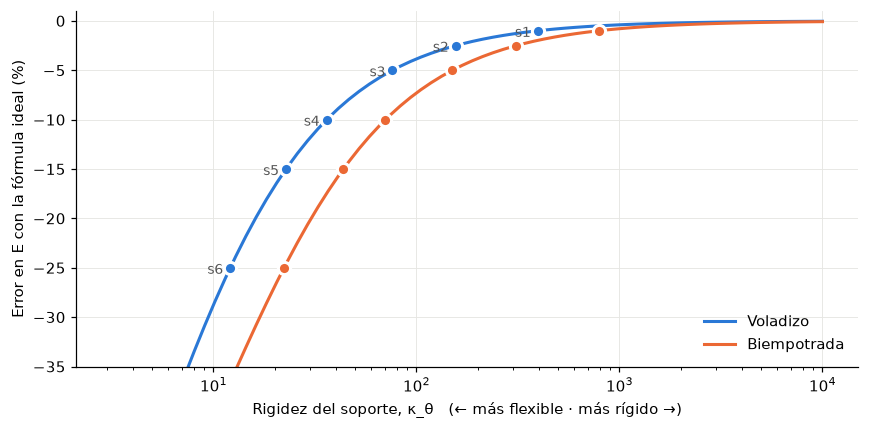

In [6]:
m1 = CALIBRACION.query("generador == 'M1'")
kappas = np.logspace(0.5, 4, 70)
fig, eje = plt.subplots(figsize=(8, 4))
for i, est in enumerate(["voladizo", "biempotrada"]):
    curva = [severidad(viga, est, Soporte(kappa_theta=k)).sesgo_E for k in kappas]
    eje.semilogx(kappas, 100 * np.array(curva), color=COLORES[i], label=est.capitalize())
    p = m1[m1.estructura == est]
    eje.plot(p.kappa_theta, 100 * p.sesgo_E, "o", color=COLORES[i], markersize=8,
             markeredgecolor="white", markeredgewidth=2)
for _, f in m1[m1.estructura == "voladizo"].iterrows():
    eje.annotate(f.nivel, (f.kappa_theta, 100 * f.sesgo_E), textcoords="offset points",
                 xytext=(-15, -4), color="#555", fontsize=9)
eje.set_xlabel("Rigidez del soporte, κ_θ   (← más flexible · más rígido →)")
eje.set_ylabel("Error en E con la fórmula ideal (%)")
eje.set_ylim(-35, 1)
eje.legend(frameon=False, loc="lower right")
fig.tight_layout()

tabla = m1.assign(error_E=100 * m1.sesgo_E, forma=100 * m1.diferencia_forma, dL=1e6 * m1.delta_L)
tabla = tabla[["nombre", "kappa_theta", "error_E", "forma", "dL"]]
tabla.columns = ["config", "κ_θ", "error en E (%)", "cambio de forma (%)", "alargamiento equivalente (µm)"]
tabla.set_index("config")

Dos observaciones:

- **La forma cambia mucho menos que la frecuencia.** En s1 y s2 el cambio de forma (≈1%) es menor que el ruido de medición que simulamos (2%). Un método que solo mire la forma casi no puede distinguir esos niveles de una viga perfecta.
- **M1 reproduce lo que vio el NIST.** Si el *mismo* soporte sostiene vigas de distinta longitud, las cortas sienten más su flexibilidad. La siguiente gráfica fija el soporte del nivel s5 y calcula el E que daría la fórmula ideal para vigas de 150 a 450 µm: E aparente sube con la longitud, igual que en las mediciones del NIST.

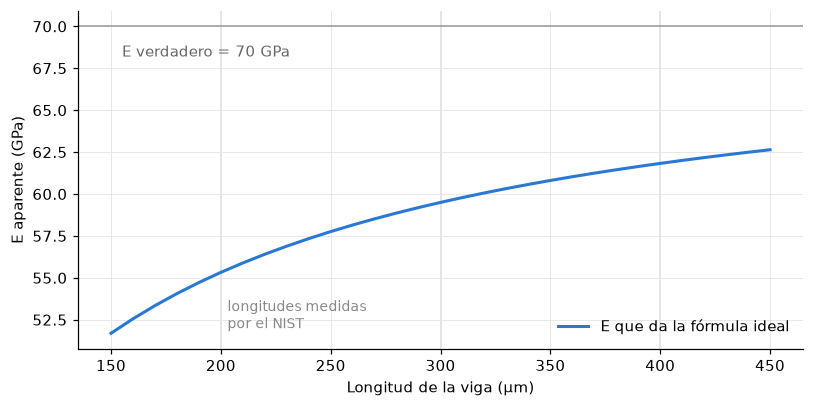

In [7]:
esc = Escalas.desde_viga(viga)
s5 = Soporte(kappa_theta=float(fila_cal("m1_voladizo_s5").kappa_theta))
k_theta_fisico, _ = esc.desde_soporte(s5)  # rigidez física del soporte, N·m/rad

longitudes = np.linspace(150e-6, 450e-6, 31)
E_aparente = []
for L in longitudes:
    v = Viga(**{**viga.__dict__, "L": L})
    E_aparente.append(viga.E * (1 + severidad(v, "voladizo", Soporte.desde_rigideces(v, k_theta_fisico, math.inf)).sesgo_E))

fig, eje = plt.subplots(figsize=(7.5, 3.8))
eje.plot(1e6 * longitudes, np.array(E_aparente) / 1e9, color=COLORES[0], label="E que da la fórmula ideal")
eje.axhline(viga.E / 1e9, color="#999", linewidth=1)
eje.text(155, viga.E / 1e9 - 1.8, "E verdadero = 70 GPa", color="#666")
for L in (200, 300, 400):
    eje.axvline(L, color="#ddd", linewidth=1, zorder=0)
eje.text(203, 52, "longitudes medidas\npor el NIST", color="#888", fontsize=9)
eje.set_xlabel("Longitud de la viga (µm)")
eje.set_ylabel("E aparente (GPa)")
eje.legend(frameon=False, loc="lower right")
fig.tight_layout()

**Severidad de M2 y M3.** Se usa un solo nivel, igualado a s3 (5% de error en E):

- **M2:** en la viga del NIST el cortante es despreciable (0.01% en E). Para que importe hay que usar una viga **más corta** con el mismo espesor: 42 µm en la biempotrada y 14 µm en el voladizo.
- **M3:** en el voladizo, la variación de espesor que da 5% de error en E (±2%). En la biempotrada la frecuencia casi no reacciona, así que se iguala el **cambio de forma** de s3.

In [8]:
ref = CALIBRACION[CALIBRACION.nombre.str.match(r"m1_.*_s3|m2_|m3_")]
pd.DataFrame({
    "config": ref.nombre,
    "error en E (%)": 100 * ref.sesgo_E,
    "cambio en ω₃ (%)": 100 * ref.corrimiento_omega3,
    "cambio de forma (%)": 100 * ref.diferencia_forma,
}).set_index("config")

,error en E (%),cambio en ω₃ (%),cambio de forma (%)
config,,,
m1_voladizo_s3,-5.00,-2.34,2.96
m2_voladizo,-5.00,-26.05,12.51
m3_voladizo,-5.00,-0.28,1.47
m1_biempotrada_s3,-5.00,-2.43,2.21
m2_biempotrada,-5.00,-9.24,2.56
m3_biempotrada,-0.03,-0.01,2.21


## 7. Un conjunto de datos, paso a paso

Cada conjunto de datos se describe con un pequeño archivo de configuración (YAML) en `datos/sinteticos/configs/`. Hay 18: M0, M1 (6 niveles), M2 y M3, cada uno para voladizo y biempotrada. Así se ve uno:

In [9]:
print((CONFIGS / "m1_voladizo_s3.yaml").read_text())

# M1, severidad s3 de 6: sesgo en E = -5.0%, ΔL = 3.87 µm.
# Generado por scripts/calibrar_severidad.py; no editar a mano.
nombre: m1_voladizo_s3
generador: M1
estructura: voladizo
params:
  E: 70000000000.0
  L: 0.0003
  b: 2.8e-05
  h: 2.743e-06
  rho: 2200.0
  sigma0: 0.0
soporte:
  kappa_theta: 76.1171
  kappa_u: .inf
muestreo:
  n_puntos: 100
  n_modos: 3
ruido:
  nivel: 0.02
  semilla: 0
malla:
  n_elem: 200



| Campo | Qué indica |
|---|---|
| `generador`, `estructura` | Qué viga simular: M0–M3, voladizo o biempotrada |
| `params` | Material y geometría en unidades SI (E en Pa, longitudes en m, densidad en kg/m³) y la tensión residual σ₀ |
| `soporte` | Solo M1: rigidez del soporte al giro (`kappa_theta`) y al desplazamiento (`kappa_u`); `.inf` significa perfectamente rígido |
| `muestreo` | Cuántos puntos y cuántos modos se miden |
| `ruido` | Nivel de ruido (0.02 = 2%) y semilla |
| `malla` | En cuántos tramos divide el cálculo a la viga |

Con esa configuración, `generar()`:

1. Construye la viga y el generador indicados (aquí M1 con κ_θ = 76).
2. Calcula frecuencias y formas modales.
3. Muestrea las formas en N = 100 puntos.
4. Agrega **ruido de medición** gaussiano de 2% de la amplitud máxima de cada modo. La **semilla** fija los números aleatorios: con la misma semilla se obtienen exactamente los mismos datos.

Los datos no se guardan en git: cualquiera los puede regenerar idénticos con `python scripts/generar_sinteticos.py`.

Frecuencias (kHz): [ 27.07 169.82 475.94]


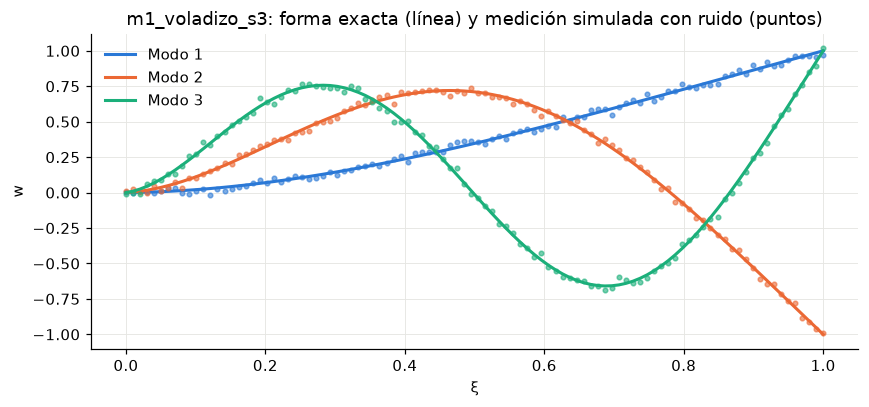

In [10]:
conjunto = generar(cargar_config(CONFIGS / "m1_voladizo_s3.yaml"))

fig, eje = plt.subplots(figsize=(8, 3.8))
for m in range(3):
    eje.plot(conjunto.xi, conjunto.w_limpia[m], color=COLORES[m], label=f"Modo {m + 1}")
    eje.plot(conjunto.xi, conjunto.w[m], "o", color=COLORES[m], markersize=3, alpha=0.6)
eje.set_title("m1_voladizo_s3: forma exacta (línea) y medición simulada con ruido (puntos)")
eje.set_xlabel("ξ")
eje.set_ylabel("w")
eje.legend(frameon=False)
fig.tight_layout()
print("Frecuencias (kHz):", np.round(conjunto.omega / (2 * np.pi * 1e3), 2))

El resultado se guarda en un archivo `.npz` (formato estándar de NumPy) que leen igual todos los métodos del proyecto:

| Campo | Contenido |
|---|---|
| `xi` | Posiciones de medición, de 0 a 1 |
| `w` | Formas modales **con ruido** (lo que "mide" el método) |
| `w_limpia` | Formas modales sin ruido (solo para análisis) |
| `omega` | Frecuencias de los modos 1–3, en rad/s |
| `estructura`, `generador` | Voladizo o biempotrada; M0–M3 |
| `params` | Todos los parámetros físicos, incluido el E verdadero |
| `ruido`, `config`, `version` | Nivel de ruido y semilla, configuración original y versión del código |

In [11]:
with tempfile.TemporaryDirectory() as carpeta:
    ruta = conjunto.guardar(Path(carpeta) / "ejemplo.npz")
    copia = Conjunto.cargar(ruta)
print("Se guarda y se lee sin cambios:", np.array_equal(copia.w, conjunto.w) and copia.params == conjunto.params)
print("E verdadero guardado en el archivo:", copia.params["E"] / 1e9, "GPa")

Se guarda y se lee sin cambios: True
E verdadero guardado en el archivo: 70.0 GPa


## 8. Cómo se usarán los datos

Cada método recibe las mediciones (`w`, `omega`) y la geometría, y estima E **usando el modelo simple**. Como sabemos el E verdadero, medimos su error. Los métodos se organizan en cuatro niveles según cuánto "desconfían" del modelo simple:

| Nivel | Idea | Ejemplos |
|---|---|---|
| **L0** | Confía totalmente en el modelo simple | Fórmula estándar de la industria, ajuste clásico, PINN con la física fija |
| **L1** | Permite que los datos se aparten un poco de la física | PINN con la física "relajada" |
| **L2** | Agrega un término genérico de corrección | PINN o ajuste clásico con un término de discrepancia |
| **L3** | Agrega la física que falta | Ajuste o PINN que también estiman la flexibilidad del soporte |

### Un primer vistazo: el método más simple

Antes de los métodos sofisticados, apliquemos a cada conjunto la fórmula ideal (un método L0): despejar E de la primera frecuencia. Es lo que se hace hoy en la industria. **En M0 acierta; en las vigas imperfectas se equivoca**, y el error crece con la severidad. Los métodos del proyecto deben reducir ese error.

estructura,biempotrada,voladizo
caso,,
m0,0.00,0.0
m1_s1,-1.00,-1.0
m1_s2,-2.50,-2.5
m1_s3,-5.00,-5.0
m1_s4,-10.00,-10.0
m1_s5,-15.00,-15.0
m1_s6,-25.00,-25.0
m2,-5.00,-5.0
m3,-0.03,-5.0


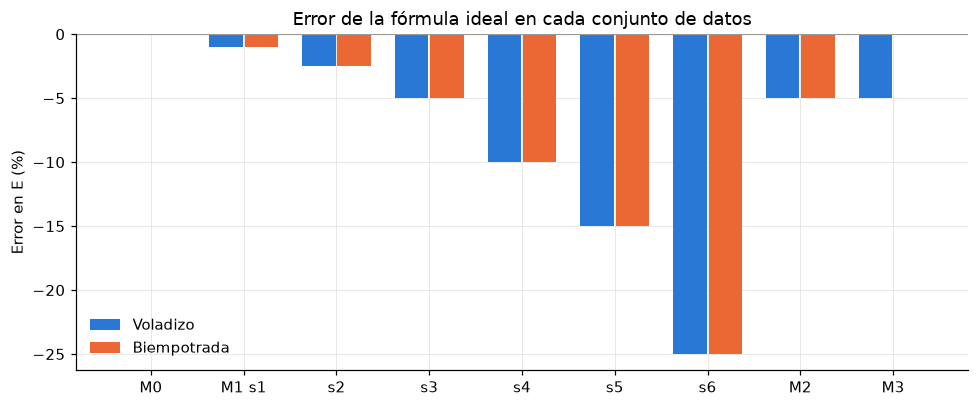

In [12]:
filas = []
for ruta in sorted(CONFIGS.glob("*.yaml")):
    c = generar(cargar_config(ruta))
    v = Viga(**{k: c.params[k] for k in ("E", "L", "b", "h", "rho", "sigma0")})
    lam_ideal = resolver_modos(v, c.estructura, n_modos=1).lam[0]  # λ₁ del modelo simple
    E_estimado = Escalas.desde_viga(v).E_desde_lambda(lam_ideal, c.omega[0])
    filas.append({"config": c.nombre, "estructura": c.estructura,
                  "error en E (%)": 100 * (E_estimado / c.params["E"] - 1)})
resultados = pd.DataFrame(filas)

orden = ["m0", *[f"m1_s{i}" for i in range(1, 7)], "m2", "m3"]
resultados["caso"] = resultados.config.str.replace(r"_(voladizo|biempotrada)", "", regex=True)
pivote = resultados.pivot(index="caso", columns="estructura", values="error en E (%)").loc[orden]

fig, eje = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(orden))
for i, est in enumerate(["voladizo", "biempotrada"]):
    eje.bar(x + (i - 0.5) * 0.38, pivote[est], width=0.36, color=COLORES[i], label=est.capitalize())
eje.axhline(0, color="#999", linewidth=0.8)
eje.set_xticks(x, ["M0", "M1 s1", "s2", "s3", "s4", "s5", "s6", "M2", "M3"])
eje.set_ylabel("Error en E (%)")
eje.set_title("Error de la fórmula ideal en cada conjunto de datos")
eje.legend(frameon=False, loc="lower left")
fig.tight_layout()
pivote.round(2)

Fíjate en **M3 de la biempotrada**: la fórmula ideal da casi 0% de error, porque la frecuencia no cambia. Pero la forma sí cambió. Un método que use las formas debería notar que algo no cuadra; uno que use solo la frecuencia, no. Este tipo de contraste es lo que el proyecto quiere medir.

### El experimento completo

Cada método se evaluará en esta matriz (tomada del plan del proyecto):

| Eje | Valores |
|---|---|
| Generador y severidad | M0, M1 (s1–s6), M2, M3 → **9 casos** |
| Puntos medidos por viga, N | 5, 15, 40 |
| Estructuras medidas, k | 1 (un voladizo) o 3 (voladizo + biempotrada + segundo voladizo) |
| Modos usados | 1 o 3 |
| Semillas de ruido | 10 (para separar el error sistemático del aleatorio) |
| Ruido | 2%, fijo |

Son 9 × 3 × 2 × 2 × 10 = **1080 corridas por método**.

### Preparación para la PINN: adimensionalización

Una red neuronal entrena mal cuando sus números tienen escalas muy distintas, y en una viga MEMS conviven valores de 10⁻²³ (momento de inercia, en m⁴) y de 10¹⁰ (E, en Pa). Por eso todo se reescribe con cantidades **sin unidades**, de tamaño parecido. El código (`pinn_mems.adimensional`) hace la conversión de ida y vuelta, y el solver usa internamente las mismas cantidades.

In [13]:
modos = resolver_modos(viga, "voladizo", s5)
w_tipico = 50e-9  # amplitud típica de vibración: 50 nm
M_tipico = viga.EI * w_tipico / viga.L**2
con_unidades = {"I (m⁴)": viga.I, "E (Pa)": viga.E, "ρA (kg/m)": viga.rho * viga.A,
                "ω₁ (rad/s)": modos.omega[0], "w (m)": w_tipico, "momento (N·m)": M_tipico}
sin_unidades = {"λ₁": esc.a_lambda(modos.omega[0]), "κ_θ": s5.kappa_theta,
                "W = w/h": esc.a_W(w_tipico), "momento adim.": esc.a_M(M_tipico), "θ = E/E_ref": 1.0}

def rango(d):
    return np.log10(max(d.values()) / min(d.values()))

print("Con unidades:", ", ".join(f"{k} = {v:.0e}" for k, v in con_unidades.items()))
print(f"  → abarcan {rango(con_unidades):.0f} órdenes de magnitud\n")
print("Sin unidades:", ", ".join(f"{k} = {v:.3g}" for k, v in sin_unidades.items()))
print(f"  → abarcan {rango(sin_unidades):.0f} órdenes de magnitud")

Con unidades: I (m⁴) = 5e-23, E (Pa) = 7e+10, ρA (kg/m) = 2e-07, ω₁ (rad/s) = 2e+05, w (m) = 5e-08, momento (N·m) = 2e-12
  → abarcan 33 órdenes de magnitud

Sin unidades: λ₁ = 10.5, κ_θ = 22.8, W = w/h = 0.0182, momento adim. = 0.0182, θ = E/E_ref = 1
  → abarcan 3 órdenes de magnitud


## 9. Limitaciones y pendientes

**Lo que ya está:** el modelo físico y su validación, los cuatro generadores, la calibración de severidad, el formato de datos y la adimensionalización. Todo tiene pruebas automáticas (`pytest`).

**Lo que falta para tener todos los datos del experimento:**
- Generar la matriz completa de la sección 8: varias semillas, N = 5/15/40 puntos y grupos de 3 estructuras que comparten el mismo material y soporte.
- Elegir un valor de tensión residual σ₀ distinto de cero. Hoy todos los conjuntos usan σ₀ = 0, y el proyecto también quiere estimar σ₀.

**Supuestos que hay que confirmar con fuentes:**
- La rigidez del soporte al **desplazamiento** (además del giro) se supone infinita. Hay que tomarla de Kobrinsky et al. (2000) y recalibrar con `scripts/calibrar_severidad.py`.
- La cifra de 5% de M-TEST (nivel s3) no se ha verificado contra la fuente original.
- El voladizo de M2 es muy corto (L/h ≈ 5): es un caso de estrés más que un dispositivo típico.

**Para reproducir todo:**
```bash
pip install -e ".[dev]"
pytest                                   # 85 pruebas
python scripts/calibrar_severidad.py     # recalcula los niveles de severidad
python scripts/generar_sinteticos.py     # genera los 18 conjuntos en datos/sinteticos/generados/
```